# Notebook 4: Decoupled Knowledge Distillation 

## 1. Imports

In [13]:
import os
import json
import time
import random
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [14]:
KAGGLE_WORKING = Path("/kaggle/working")
KAGGLE_INPUT = Path("/kaggle/input")
BASE_OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else Path.cwd() / "outputs"

CONFIG = {
    "method": "DKD",
    "model": "resnet20",
    "teacher_model": "resnet110",
    "dataset": "CIFAR100",
    "num_classes": 100,
    "epochs": 200,
    "batch_size": 128,
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "scheduler": "MultiStepLR",
    "milestones": [100, 150],
    "gamma": 0.1,
    "temperature": 4.0,
    "alpha_dkd": 1.0,
    "beta_dkd": 3.0,
    "loss": "CrossEntropy + Decoupled KD",
    "student_initialization": "from_scratch",
    "seed": 42,
    "mixed_precision": True,
    "num_workers": 2,
    "pin_memory": True,
    "run_beta_ablation": False,
    "beta_ablation_values": [2.0, 4.0, 8.0, 12.0],
    "ablation_epochs": 200,
    "quick_sanity_check": False,
    "sanity_epochs": 1,
    "teacher_checkpoint": "ekd_paper_teacher_resnet110_best.pth",
    "student_ce_checkpoint": "student_resnet20_ce_best.pth",
    "teacher_input_dir": "/kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110-fixed-eval/pytorch/default/1",
    "teacher_input_dir_fallback": "/kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110/pytorch/default/1",
    "teacher_artifact_stage_dir": "ekd_paper_teacher_resnet110",
    "student_ce_input_dir": "/kaggle/input/models/zaidiftikhar/dl-prod-student-ce/pytorch/default/1",
    "output_root": str(BASE_OUTPUT_DIR / "kd_cifar100_artifacts"),
    "stage_dir": "dkd_with_ekd_teacher",
    "config_filename": "dkd_with_ekd_teacher_config.json",
}

if CONFIG["quick_sanity_check"]:
    CONFIG["epochs"] = CONFIG["sanity_epochs"]
    CONFIG["ablation_epochs"] = CONFIG["sanity_epochs"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
CONFIG


Using device: cuda


{'method': 'DKD',
 'model': 'resnet20',
 'teacher_model': 'resnet110',
 'dataset': 'CIFAR100',
 'num_classes': 100,
 'epochs': 200,
 'batch_size': 128,
 'optimizer': 'SGD',
 'learning_rate': 0.1,
 'momentum': 0.9,
 'weight_decay': 0.0005,
 'scheduler': 'MultiStepLR',
 'milestones': [100, 150],
 'gamma': 0.1,
 'temperature': 4.0,
 'alpha_dkd': 1.0,
 'beta_dkd': 3.0,
 'loss': 'CrossEntropy + Decoupled KD',
 'student_initialization': 'from_scratch',
 'seed': 42,
 'mixed_precision': True,
 'num_workers': 2,
 'pin_memory': True,
 'run_beta_ablation': False,
 'beta_ablation_values': [2.0, 4.0, 8.0, 12.0],
 'ablation_epochs': 200,
 'quick_sanity_check': False,
 'sanity_epochs': 1,
 'teacher_checkpoint': 'ekd_paper_teacher_resnet110_best.pth',
 'student_ce_checkpoint': 'student_resnet20_ce_best.pth',
 'teacher_input_dir': '/kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110-fixed-eval/pytorch/default/1',
 'teacher_input_dir_fallback': '/kaggle/input/models/zaidiftikhar/ekd-paper-teac

## 3. Reproducibility and Output Directories

In [15]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG["seed"])

stage_root = Path(CONFIG["output_root"]) / CONFIG["stage_dir"]
checkpoint_dir = stage_root / "checkpoints"
log_dir = stage_root / "logs"
config_dir = stage_root / "config"
plot_dir = stage_root / "plots"

for directory in [checkpoint_dir, log_dir, config_dir, plot_dir]:
    directory.mkdir(parents=True, exist_ok=True)

config_path = config_dir / CONFIG["config_filename"]
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print(f"Artifacts directory: {stage_root}")
print(f"Saved config: {config_path}")


Artifacts directory: /kaggle/working/kd_cifar100_artifacts/dkd_with_ekd_teacher
Saved config: /kaggle/working/kd_cifar100_artifacts/dkd_with_ekd_teacher/config/dkd_with_ekd_teacher_config.json


## 4. Dataset

In [16]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

data_root = KAGGLE_WORKING / "data" if KAGGLE_WORKING.exists() else Path("./data")
train_dataset = datasets.CIFAR100(root=str(data_root), train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR100(root=str(data_root), train=False, download=True, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
)

class_names = train_dataset.classes
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {len(class_names)}")


Train samples: 50000
Test samples: 10000
Classes: 100


## 5. CIFAR ResNet

In [17]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class CIFARResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super().__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64 * block.expansion, num_classes)
        self._initialize_weights()

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for block_stride in strides:
            layers.append(block(self.in_planes, planes, block_stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def resnet20(num_classes=100):
    return CIFARResNet(BasicBlock, [3, 3, 3], num_classes=num_classes)


def resnet110(num_classes=100):
    return CIFARResNet(BasicBlock, [18, 18, 18], num_classes=num_classes)


## 6. Load Teacher and CE Student

In [18]:
def find_checkpoint(filename, preferred_stage_dir, explicit_input_dir=None, extra_input_dirs=None):
    search_roots = []
    if explicit_input_dir:
        search_roots.append(Path(explicit_input_dir))
    if extra_input_dirs:
        for extra_dir in extra_input_dirs:
            if extra_dir:
                search_roots.append(Path(extra_dir))
    if KAGGLE_INPUT.exists():
        search_roots.extend(sorted(KAGGLE_INPUT.glob("*")))
    search_roots.extend([
        Path(CONFIG["output_root"]),
        Path.cwd() / "kd_cifar100_artifacts",
        Path.cwd() / "outputs" / "kd_cifar100_artifacts",
    ])

    candidates = []
    for root in search_roots:
        if not root.exists():
            continue
        direct_patterns = [
            root / preferred_stage_dir / "checkpoints" / filename,
            root / CONFIG.get("teacher_artifact_stage_dir", preferred_stage_dir) / "checkpoints" / filename,
            root / "checkpoints" / filename,
            root / filename,
        ]
        candidates.extend([p for p in direct_patterns if p.exists()])
        candidates.extend(root.rglob(filename))

    unique = []
    seen = set()
    for path in candidates:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(path)
    if not unique:
        raise FileNotFoundError(f"Could not find {filename}. Check the Kaggle input model paths in CONFIG.")
    return unique[0]


def remap_official_resnet_keys(state_dict):
    # EKD teacher notebooks use the official mdistiller ResNet naming: layer*.0.downsample.*
    # This DKD notebook uses the earlier local naming: layer*.0.shortcut.*
    remapped = {}
    for key, value in state_dict.items():
        new_key = key
        new_key = new_key.replace("layer2.0.downsample.", "layer2.0.shortcut.")
        new_key = new_key.replace("layer3.0.downsample.", "layer3.0.shortcut.")
        remapped[new_key] = value
    return remapped


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ["model_state_dict", "student_state_dict", "state_dict"]:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                return checkpoint[key]
        if "model" in checkpoint and isinstance(checkpoint["model"], dict):
            return checkpoint["model"]
    return checkpoint


def load_checkpoint_into_model(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = extract_state_dict(checkpoint)
    try:
        model.load_state_dict(state_dict)
    except RuntimeError as error:
        remapped_state_dict = remap_official_resnet_keys(state_dict)
        model.load_state_dict(remapped_state_dict)
        print("Loaded checkpoint after remapping official ResNet downsample keys to local shortcut keys.")
    return checkpoint

teacher_checkpoint_path = find_checkpoint(
    CONFIG["teacher_checkpoint"],
    CONFIG["teacher_artifact_stage_dir"],
    explicit_input_dir=CONFIG["teacher_input_dir"],
    extra_input_dirs=[CONFIG.get("teacher_input_dir_fallback")],
)
student_ce_checkpoint_path = find_checkpoint(
    CONFIG["student_ce_checkpoint"],
    "student_resnet20_ce",
    explicit_input_dir=CONFIG["student_ce_input_dir"],
)
print(f"Teacher checkpoint: {teacher_checkpoint_path}")
print(f"CE student checkpoint: {student_ce_checkpoint_path}")

teacher = resnet110(num_classes=CONFIG["num_classes"]).to(device)
teacher_ckpt = load_checkpoint_into_model(teacher, teacher_checkpoint_path, device)
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

student_ce = resnet20(num_classes=CONFIG["num_classes"]).to(device)
student_ce_ckpt = load_checkpoint_into_model(student_ce, student_ce_checkpoint_path, device)
student_ce.eval()


Teacher checkpoint: /kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110-fixed-eval/pytorch/default/1/ekd_paper_teacher_resnet110_best.pth
CE student checkpoint: /kaggle/input/models/zaidiftikhar/dl-prod-student-ce/pytorch/default/1/student_resnet20_ce_best.pth
Loaded checkpoint after remapping official ResNet downsample keys to local shortcut keys.


CIFARResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affi

## 7. Utilities

In [19]:
def accuracy_from_logits(logits, labels):
    return logits.argmax(dim=1).eq(labels).sum().item()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += accuracy_from_logits(logits, labels)
        running_total += batch_size
    return running_loss / running_total, 100.0 * running_correct / running_total


def save_checkpoint(path, epoch, model, optimizer, scheduler, best_acc, config, train_dataset):
    checkpoint = {
        "epoch": epoch,
        "model_name": config["model"],
        "teacher_model": config["teacher_model"],
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_acc": best_acc,
        "config": config,
        "class_to_idx": train_dataset.class_to_idx,
        "classes": train_dataset.classes,
    }
    torch.save(checkpoint, path)

def plot_curves(log_df, method_label, accuracy_path, loss_path, extra_loss_path=None):
    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["train_acc"], label="Train Accuracy")
    plt.plot(log_df["epoch"], log_df["test_acc"], label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{method_label} Accuracy on CIFAR-100")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(accuracy_path, dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["train_loss"], label="Total Loss")
    plt.plot(log_df["epoch"], log_df["test_loss"], label="Test CE Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{method_label} Loss on CIFAR-100")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(loss_path, dpi=200)
    plt.show()

    if extra_loss_path is not None:
        plt.figure(figsize=(8, 5))
        for column in [c for c in log_df.columns if c.endswith("_loss") and c not in ["train_loss", "test_loss"]]:
            plt.plot(log_df["epoch"], log_df[column], label=column)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"{method_label} Loss Components")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(extra_loss_path, dpi=200)
        plt.show()


def plot_gap_reduction(teacher_acc, ce_acc, method_acc, method_name, path):
    plt.figure(figsize=(7, 5))
    gaps = [teacher_acc - ce_acc, teacher_acc - method_acc]
    bars = plt.bar(["CE Gap", f"{method_name} Gap"], gaps, color=["#70AD47", "#C55A11"])
    plt.ylabel("Gap from Teacher (points)")
    plt.title(f"{method_name} Teacher-Student Gap Reduction")
    plt.grid(axis="y", alpha=0.3)
    for bar, value in zip(bars, gaps):
        plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.2f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()


## 8. DKD Loss

In [20]:
def cat_mask(probabilities, labels):
    gt_mask = F.one_hot(labels, num_classes=probabilities.size(1)).bool()
    target_prob = probabilities[gt_mask].view(-1, 1)
    non_target_prob = probabilities.masked_fill(gt_mask, 0).sum(dim=1, keepdim=True)
    return torch.cat([target_prob, non_target_prob], dim=1)


def dkd_loss_fn(student_logits, teacher_logits, labels, temperature, alpha_dkd, beta_dkd):
    ce_loss = F.cross_entropy(student_logits, labels)
    gt_mask = F.one_hot(labels, num_classes=student_logits.size(1)).bool()

    student_probs = F.softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    student_cat_log_probs = torch.log(cat_mask(student_probs, labels).clamp_min(1e-12))
    teacher_cat_probs = cat_mask(teacher_probs, labels)
    tckd_loss = F.kl_div(student_cat_log_probs, teacher_cat_probs, reduction="batchmean") * (temperature * temperature)

    large_negative = 1000.0
    student_non_target_log_probs = F.log_softmax(student_logits / temperature - gt_mask.float() * large_negative, dim=1)
    teacher_non_target_probs = F.softmax(teacher_logits / temperature - gt_mask.float() * large_negative, dim=1)
    nckd_loss = F.kl_div(student_non_target_log_probs, teacher_non_target_probs, reduction="batchmean") * (temperature * temperature)

    total_loss = ce_loss + alpha_dkd * tckd_loss + beta_dkd * nckd_loss
    return total_loss, ce_loss.detach(), tckd_loss.detach(), nckd_loss.detach()


## 9. Train DKD Student

In [21]:
def train_dkd(alpha_dkd, beta_dkd, epochs, run_name="student_resnet20_dkd"):
    set_seed(CONFIG["seed"])
    student = resnet20(num_classes=CONFIG["num_classes"]).to(device)
    optimizer = optim.SGD(student.parameters(), lr=CONFIG["learning_rate"], momentum=CONFIG["momentum"], weight_decay=CONFIG["weight_decay"])
    scheduler = MultiStepLR(optimizer, milestones=CONFIG["milestones"], gamma=CONFIG["gamma"])
    scaler = GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())

    best_path = checkpoint_dir / f"{run_name}_best.pth"
    last_path = checkpoint_dir / f"{run_name}_last.pth"
    log_path = log_dir / "dkd_training_log.csv" if run_name == "student_resnet20_dkd" else log_dir / f"{run_name}_log.csv"
    run_config = CONFIG.copy()
    run_config.update({"alpha_dkd": alpha_dkd, "beta_dkd": beta_dkd, "run_name": run_name, "epochs": epochs})

    log_records = []
    best_acc = 0.0
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        student.train()
        totals = {"loss": 0.0, "ce": 0.0, "tckd": 0.0, "nckd": 0.0, "correct": 0, "count": 0}
        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.no_grad():
                teacher_logits = teacher(images)
            with autocast(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available()):
                student_logits = student(images)
                loss, ce_loss, tckd_loss, nckd_loss = dkd_loss_fn(
                    student_logits, teacher_logits, labels, CONFIG["temperature"], alpha_dkd, beta_dkd
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.size(0)
            totals["loss"] += loss.item() * batch_size
            totals["ce"] += ce_loss.item() * batch_size
            totals["tckd"] += tckd_loss.item() * batch_size
            totals["nckd"] += nckd_loss.item() * batch_size
            totals["correct"] += accuracy_from_logits(student_logits, labels)
            totals["count"] += batch_size

        train_loss = totals["loss"] / totals["count"]
        train_acc = 100.0 * totals["correct"] / totals["count"]
        test_loss, test_acc = evaluate(student, test_loader, device)
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        if test_acc > best_acc:
            best_acc = test_acc
            save_checkpoint(best_path, epoch, student, optimizer, scheduler, best_acc, run_config, train_dataset)
        save_checkpoint(last_path, epoch, student, optimizer, scheduler, best_acc, run_config, train_dataset)

        record = {
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_loss,
            "ce_loss": totals["ce"] / totals["count"],
            "tckd_loss": totals["tckd"] / totals["count"],
            "nckd_loss": totals["nckd"] / totals["count"],
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "best_test_acc": best_acc,
            "epoch_time_sec": time.time() - epoch_start,
        }
        log_records.append(record)
        pd.DataFrame(log_records).to_csv(log_path, index=False)
        print(f"{run_name} | Epoch {epoch:03d}/{epochs:03d} | train {train_loss:.4f}, acc {train_acc:.2f}% | test {test_acc:.2f}% | best {best_acc:.2f}%")

    return {
        "run_name": run_name,
        "best_test_acc": best_acc,
        "final_test_acc": log_records[-1]["test_acc"],
        "final_train_acc": log_records[-1]["train_acc"],
        "training_time_seconds": time.time() - start_time,
        "checkpoint_path": str(best_path),
        "last_checkpoint_path": str(last_path),
        "log_path": str(log_path),
    }

teacher_test_loss, teacher_test_acc = evaluate(teacher, test_loader, device)
student_ce_test_loss, student_ce_test_acc = evaluate(student_ce, test_loader, device)
print(f"EKD evidential teacher accuracy: {teacher_test_acc:.2f}%")
print(f"CE student accuracy: {student_ce_test_acc:.2f}%")

dkd_result = train_dkd(CONFIG["alpha_dkd"], CONFIG["beta_dkd"], CONFIG["epochs"])


EKD evidential teacher accuracy: 73.69%
CE student accuracy: 69.47%


/tmp/ipykernel_57/2173149574.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())
/tmp/ipykernel_57/2173149574.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available()):


student_resnet20_dkd | Epoch 001/200 | train 33.4898, acc 8.24% | test 11.64% | best 11.64%
student_resnet20_dkd | Epoch 002/200 | train 27.2753, acc 19.96% | test 23.41% | best 23.41%
student_resnet20_dkd | Epoch 003/200 | train 23.2241, acc 29.15% | test 30.74% | best 30.74%
student_resnet20_dkd | Epoch 004/200 | train 20.6127, acc 36.87% | test 33.69% | best 33.69%
student_resnet20_dkd | Epoch 005/200 | train 18.8566, acc 41.19% | test 38.29% | best 38.29%
student_resnet20_dkd | Epoch 006/200 | train 17.6694, acc 44.67% | test 39.98% | best 39.98%
student_resnet20_dkd | Epoch 007/200 | train 16.7922, acc 47.39% | test 44.52% | best 44.52%
student_resnet20_dkd | Epoch 008/200 | train 16.1059, acc 49.38% | test 42.74% | best 44.52%
student_resnet20_dkd | Epoch 009/200 | train 15.5953, acc 50.86% | test 43.39% | best 44.52%
student_resnet20_dkd | Epoch 010/200 | train 15.2633, acc 51.95% | test 43.62% | best 44.52%
student_resnet20_dkd | Epoch 011/200 | train 14.8060, acc 53.46% | test

## 10. Save Plots, Ablations, and Summary

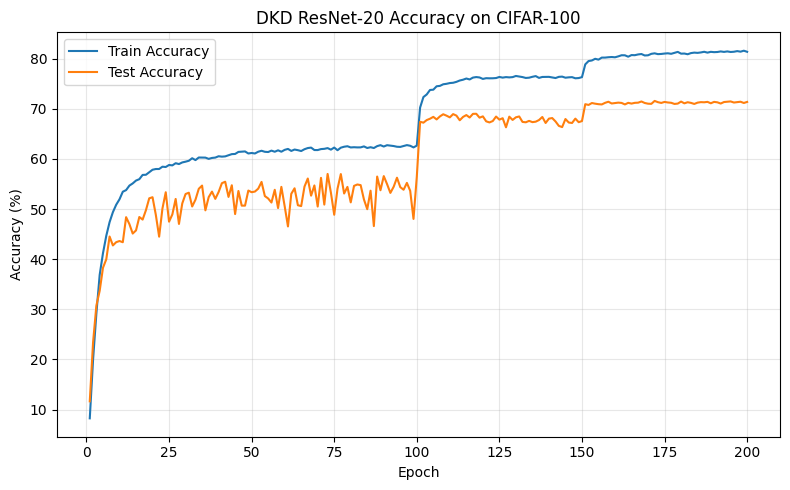

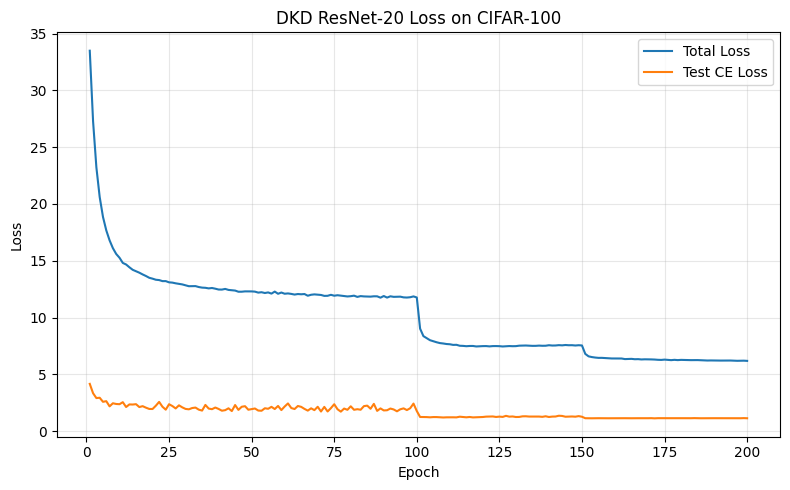

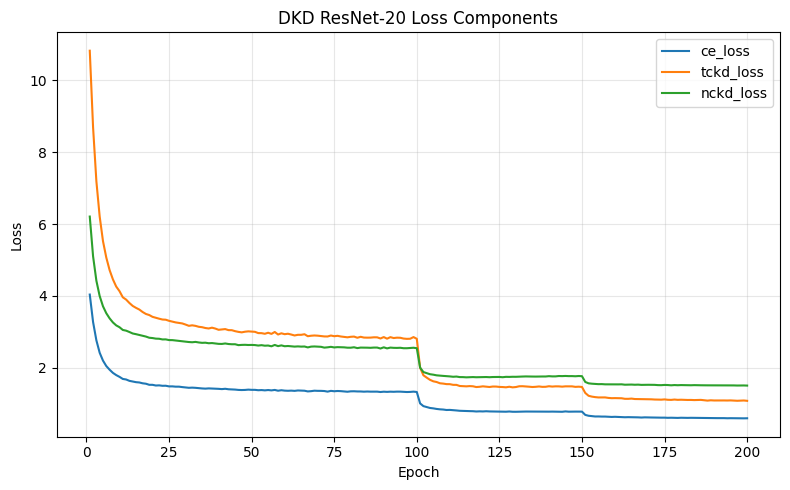

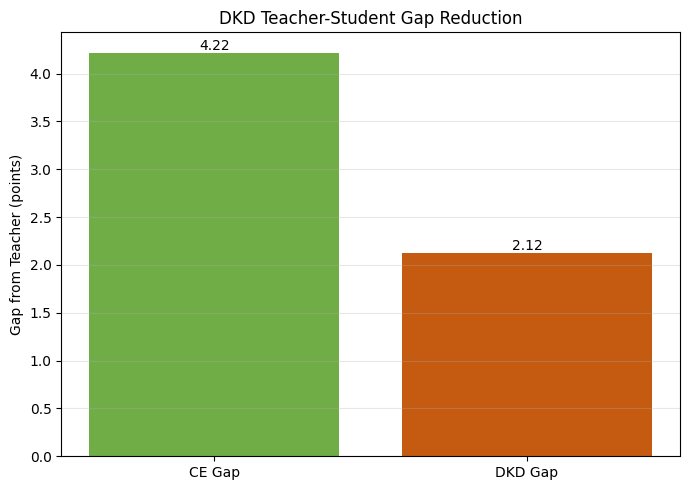

DKD summary
method: DKD
model: ResNet20
teacher: ResNet110 Evidential Teacher
dataset: CIFAR100
best_test_acc: 71.57
final_test_acc: 71.37
final_train_acc: 81.374
teacher_acc: 73.69
ce_student_acc: 69.47
gap_from_teacher: 2.1200000000000045
improvement_over_ce: 2.0999999999999943
params: 278324
epochs: 200
batch_size: 128
optimizer: SGD
scheduler: MultiStepLR
seed: 42
temperature: 4.0
alpha_dkd: 1.0
beta_dkd: 3.0
checkpoint_path: /kaggle/working/kd_cifar100_artifacts/dkd_with_ekd_teacher/checkpoints/student_resnet20_dkd_best.pth
training_time_seconds: 4814.167143821716
teacher_checkpoint: /kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110-fixed-eval/pytorch/default/1/ekd_paper_teacher_resnet110_best.pth
teacher_source: EKD evidential teacher trained by notebooks/finalized/ekd-teacher-rs110.ipynb
student_ce_checkpoint: /kaggle/input/models/zaidiftikhar/dl-prod-student-ce/pytorch/default/1/student_resnet20_ce_best.pth
Saved summary: /kaggle/working/kd_cifar100_artifacts/dkd_wi

In [22]:
log_df = pd.read_csv(dkd_result["log_path"])
plot_curves(
    log_df,
    "DKD ResNet-20",
    plot_dir / "dkd_accuracy_curve.png",
    plot_dir / "dkd_loss_curve.png",
    plot_dir / "dkd_tckd_nckd_losses.png",
)
plot_gap_reduction(teacher_test_acc, student_ce_test_acc, dkd_result["best_test_acc"], "DKD", plot_dir / "dkd_gap_reduction.png")

ablation_rows = []
if CONFIG["run_beta_ablation"]:
    for beta in CONFIG["beta_ablation_values"]:
        run = train_dkd(CONFIG["alpha_dkd"], beta, CONFIG["ablation_epochs"], run_name=f"student_resnet20_dkd_b{int(beta)}")
        run["beta_dkd"] = beta
        ablation_rows.append(run)

ablation_df = pd.DataFrame(ablation_rows)
ablation_path = log_dir / "dkd_ablation_results.csv"
ablation_df.to_csv(ablation_path, index=False)

dkd_summary = {
    "method": "DKD",
    "model": "ResNet20",
    "teacher": "ResNet110 Evidential Teacher",
    "dataset": "CIFAR100",
    "best_test_acc": dkd_result["best_test_acc"],
    "final_test_acc": dkd_result["final_test_acc"],
    "final_train_acc": dkd_result["final_train_acc"],
    "teacher_acc": teacher_test_acc,
    "ce_student_acc": student_ce_test_acc,
    "gap_from_teacher": teacher_test_acc - dkd_result["best_test_acc"],
    "improvement_over_ce": dkd_result["best_test_acc"] - student_ce_test_acc,
    "params": sum(p.numel() for p in resnet20(CONFIG["num_classes"]).parameters()),
    "epochs": CONFIG["epochs"],
    "batch_size": CONFIG["batch_size"],
    "optimizer": CONFIG["optimizer"],
    "scheduler": CONFIG["scheduler"],
    "seed": CONFIG["seed"],
    "temperature": CONFIG["temperature"],
    "alpha_dkd": CONFIG["alpha_dkd"],
    "beta_dkd": CONFIG["beta_dkd"],
    "checkpoint_path": dkd_result["checkpoint_path"],
    "training_time_seconds": dkd_result["training_time_seconds"],
    "teacher_checkpoint": str(teacher_checkpoint_path),
    "teacher_source": "EKD evidential teacher trained by notebooks/finalized/ekd-teacher-rs110.ipynb",
    "student_ce_checkpoint": str(student_ce_checkpoint_path),
}
summary_path = stage_root / "dkd_summary.json"
with open(summary_path, "w") as f:
    json.dump(dkd_summary, f, indent=4)

zip_path = shutil.make_archive(str(BASE_OUTPUT_DIR / "dkd_with_ekd_teacher_artifacts"), "zip", root_dir=stage_root.parent, base_dir=stage_root.name)
print("DKD summary")
for key, value in dkd_summary.items():
    print(f"{key}: {value}")
print(f"Saved summary: {summary_path}")
print(f"Created zip: {zip_path}")
